# 01 - Exploratory Data Analysis
## Banking DS Project - Give Me Some Credit 

**Objetivo:** Entender la estructura, distribución y calidad del dataset antes de cualquier transformación.

**Dataset:** cs-training.csv - 150.000 clientes, scoring crediticio.
**Autor:** Alberto José Ramírez Céspedes
**Fecha:** 2026-04-20
**Entorno:** Python (banking-ds)


In [2]:
# _____Imports_____________________________________________________________________________________
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

# _____Configuración de visualización_______________________________________________________________
pd.set_option('display.max_columns', None) # Mostrar todas las columnas
pd.set_option('display.float_format', '{:.2f}'.format) # 2 decimales
sns.set_theme(style='whitegrid') # Estilo base para todos los gráficos

print("✓ Librerías cargadas correctamente.")

✓ Librerías cargadas correctamente.


## 1. Carga y estructura del dataset

In [3]:
# Cargar el dataset
df = pd.read_csv('../data/raw/cs-training.csv', index_col = 0)

# Primera inspección
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas.")
print(f"\n Tipos de datos: ")
print(df.dtypes)

Dimensiones: 150,000 filas x 11 columnas.

 Tipos de datos: 
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object


In [4]:
df.head(5)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.77,45,2,0.80,9120.00,13,0,6,0,2.00
2,0,0.96,40,0,0.12,2600.00,4,0,0,0,1.00
3,0,0.66,38,1,0.09,3042.00,2,1,0,0,0.00
4,0,0.23,30,0,0.04,3300.00,5,0,0,0,0.00
5,0,0.91,49,1,0.02,63588.00,7,0,1,0,0.00


## 2. Calidad de datos - nulos 

In [5]:
# Análisis de valores nulos 
nulos = df.isnull().sum()
pct_nulos = (df.isnull().sum() / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
        'Nulos': nulos, 
        '% del total' : pct_nulos
})

print(resumen_nulos[resumen_nulos['Nulos'] > 0])
print(f"\nTotal filas: {len(df):,}")

                    Nulos  % del total
MonthlyIncome       29731        19.82
NumberOfDependents   3924         2.62

Total filas: 150,000


In [6]:
# ¿Cómo se distribuyen los ingresos? Primeras estadísticas
print(df['MonthlyIncome'].describe())

count    120269.00
mean       6670.22
std       14384.67
min           0.00
25%        3400.00
50%        5400.00
75%        8249.00
max     3008750.00
Name: MonthlyIncome, dtype: float64


## 3. Calidad de datos - Tipos y valores únicos

In [7]:
# Exploración de valores únicos por columna
for columna in df.columns:
    n_unicos = df[columna].nunique()
    muestra = df[columna].dropna().unique()[:5]
    print(f"{columna: <45} únicos: {n_unicos: <8} muestra: {muestra}")

SeriousDlqin2yrs                              únicos: 2        muestra: [1 0]
RevolvingUtilizationOfUnsecuredLines          únicos: 125728   muestra: [0.76612661 0.95715102 0.65818014 0.23380978 0.9072394 ]
age                                           únicos: 86       muestra: [45 40 38 30 49]
NumberOfTime30-59DaysPastDueNotWorse          únicos: 16       muestra: [2 0 1 3 4]
DebtRatio                                     únicos: 114194   muestra: [0.80298213 0.1218762  0.08511338 0.03604968 0.0249257 ]
MonthlyIncome                                 únicos: 13594    muestra: [ 9120.  2600.  3042.  3300. 63588.]
NumberOfOpenCreditLinesAndLoans               únicos: 58       muestra: [13  4  2  5  7]
NumberOfTimes90DaysLate                       únicos: 19       muestra: [0 1 3 2 5]
NumberRealEstateLoansOrLines                  únicos: 28       muestra: [6 0 1 3 4]
NumberOfTime60-89DaysPastDueNotWorse          únicos: 13       muestra: [0 1 2 5 3]
NumberOfDependents                       

## 4. Estadísticas descriptivas - valores extremos

In [8]:
# Estadísticas descriptivas de todo el dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.00,0.07,0.25,0.00,0.00,0.00,0.00,1.00
RevolvingUtilizationOfUnsecuredLines,150000.00,6.05,249.76,0.00,0.03,0.15,0.56,50708.00
age,150000.00,52.30,14.77,0.00,41.00,52.00,63.00,109.00
NumberOfTime30-59DaysPastDueNotWorse,150000.00,0.42,4.19,0.00,0.00,0.00,0.00,98.00
DebtRatio,150000.00,353.01,2037.82,0.00,0.18,0.37,0.87,329664.00
MonthlyIncome,120269.00,6670.22,14384.67,0.00,3400.00,5400.00,8249.00,3008750.00
NumberOfOpenCreditLinesAndLoans,150000.00,8.45,5.15,0.00,5.00,8.00,11.00,58.00
NumberOfTimes90DaysLate,150000.00,0.27,4.17,0.00,0.00,0.00,0.00,98.00
NumberRealEstateLoansOrLines,150000.00,1.02,1.13,0.00,0.00,1.00,2.00,54.00
NumberOfTime60-89DaysPastDueNotWorse,150000.00,0.24,4.16,0.00,0.00,0.00,0.00,98.00


## 5. Investigación de outliers extremos 

In [9]:
# Variables de mora - inspeccionamos sus valores máximos
columnas_mora = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

for col in columnas_mora:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index().tail(10))


NumberOfTime30-59DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse
6     140
7      54
8      25
9      12
10      4
11      1
12      2
13      1
96      5
98    264
Name: count, dtype: int64

NumberOfTimes90DaysLate
NumberOfTimes90DaysLate
9      19
10      8
11      5
12      2
13      4
14      2
15      2
17      1
96      5
98    264
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse
NumberOfTime60-89DaysPastDueNotWorse
3     318
4     105
5      34
6      16
7       9
8       2
9       1
11      1
96      5
98    264
Name: count, dtype: int64


In [10]:
# Verificamos la tercera columna de mora
print(df['NumberOfTime60-89DaysPastDueNotWorse'].value_counts().sort_index().tail(10))

NumberOfTime60-89DaysPastDueNotWorse
3     318
4     105
5      34
6      16
7       9
8       2
9       1
11      1
96      5
98    264
Name: count, dtype: int64


## 4. Distribución de la variable objetivo 

In [11]:
# Contamos cuántos clientes tienen default (1) y cuantos no (0)
conteo_target = df['SeriousDlqin2yrs'].value_counts()
porcentaje_target = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

print("Conteo absoluto: ")
print(conteo_target)
print("\nPorcentaje:")
print(porcentaje_target.round(2))

Conteo absoluto: 
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Porcentaje:
SeriousDlqin2yrs
0   93.32
1    6.68
Name: proportion, dtype: float64


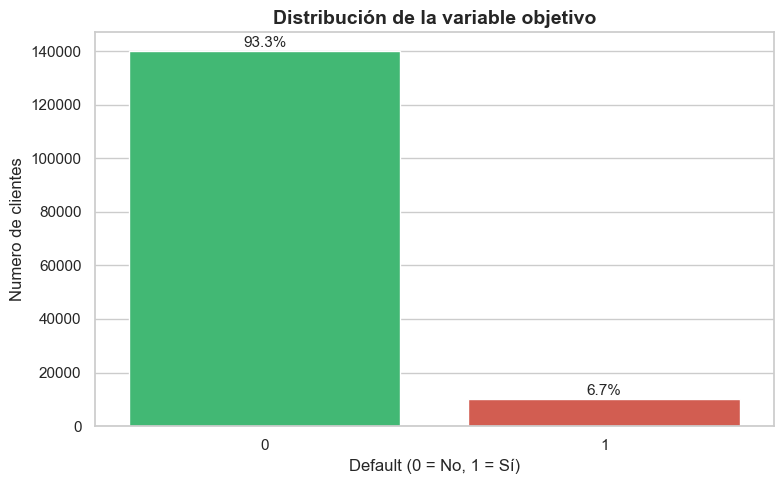

In [12]:
import matplotlib.pyplot as plt 
import seaborn as sns 

# Configuraciôn visual base - la usaremos en todos los gráficos del proyecto 
sns.set_theme(style="whitegrid")

# Creamos el lienzo 
fig, ax = plt.subplots(figsize=(8,5))

# Dibujamos el gráfico de barras 
sns.countplot(
    x='SeriousDlqin2yrs',
    data=df,
    hue='SeriousDlqin2yrs',
    palette=['#2ecc71', '#e74c3c'],
    legend=False,
    ax=ax
)

# Etiqueta y titulo 
ax.set_title('Distribución de la variable objetivo', fontsize = 14, fontweight = 'bold')
ax.set_xlabel('Default (0 = No, 1 = Sí)', fontsize=12)
ax.set_ylabel('Numero de clientes', fontsize=12)


# Añadimos el porcentaje encima de cada barra
for p in ax.patches:
    porcentaje = f'{p.get_height()/len(df)*100:.1f}%'  # calcula el % con 1 decimal
    ax.annotate(
        porcentaje,                          # texto a mostrar
        (p.get_x() + p.get_width() / 2,     # coordenada X: centro de la barra
         p.get_height() + 500),              # coordenada Y: cima + margen
        ha='center',                         # centrado horizontalmente
        va='bottom',                         # anclado desde abajo del texto
        fontsize=11                          # tamaño legible para un reporte
    )

plt.tight_layout()  # ajusta márgenes automáticamente para que nada se corte
plt.show()          # renderiza el gráfico

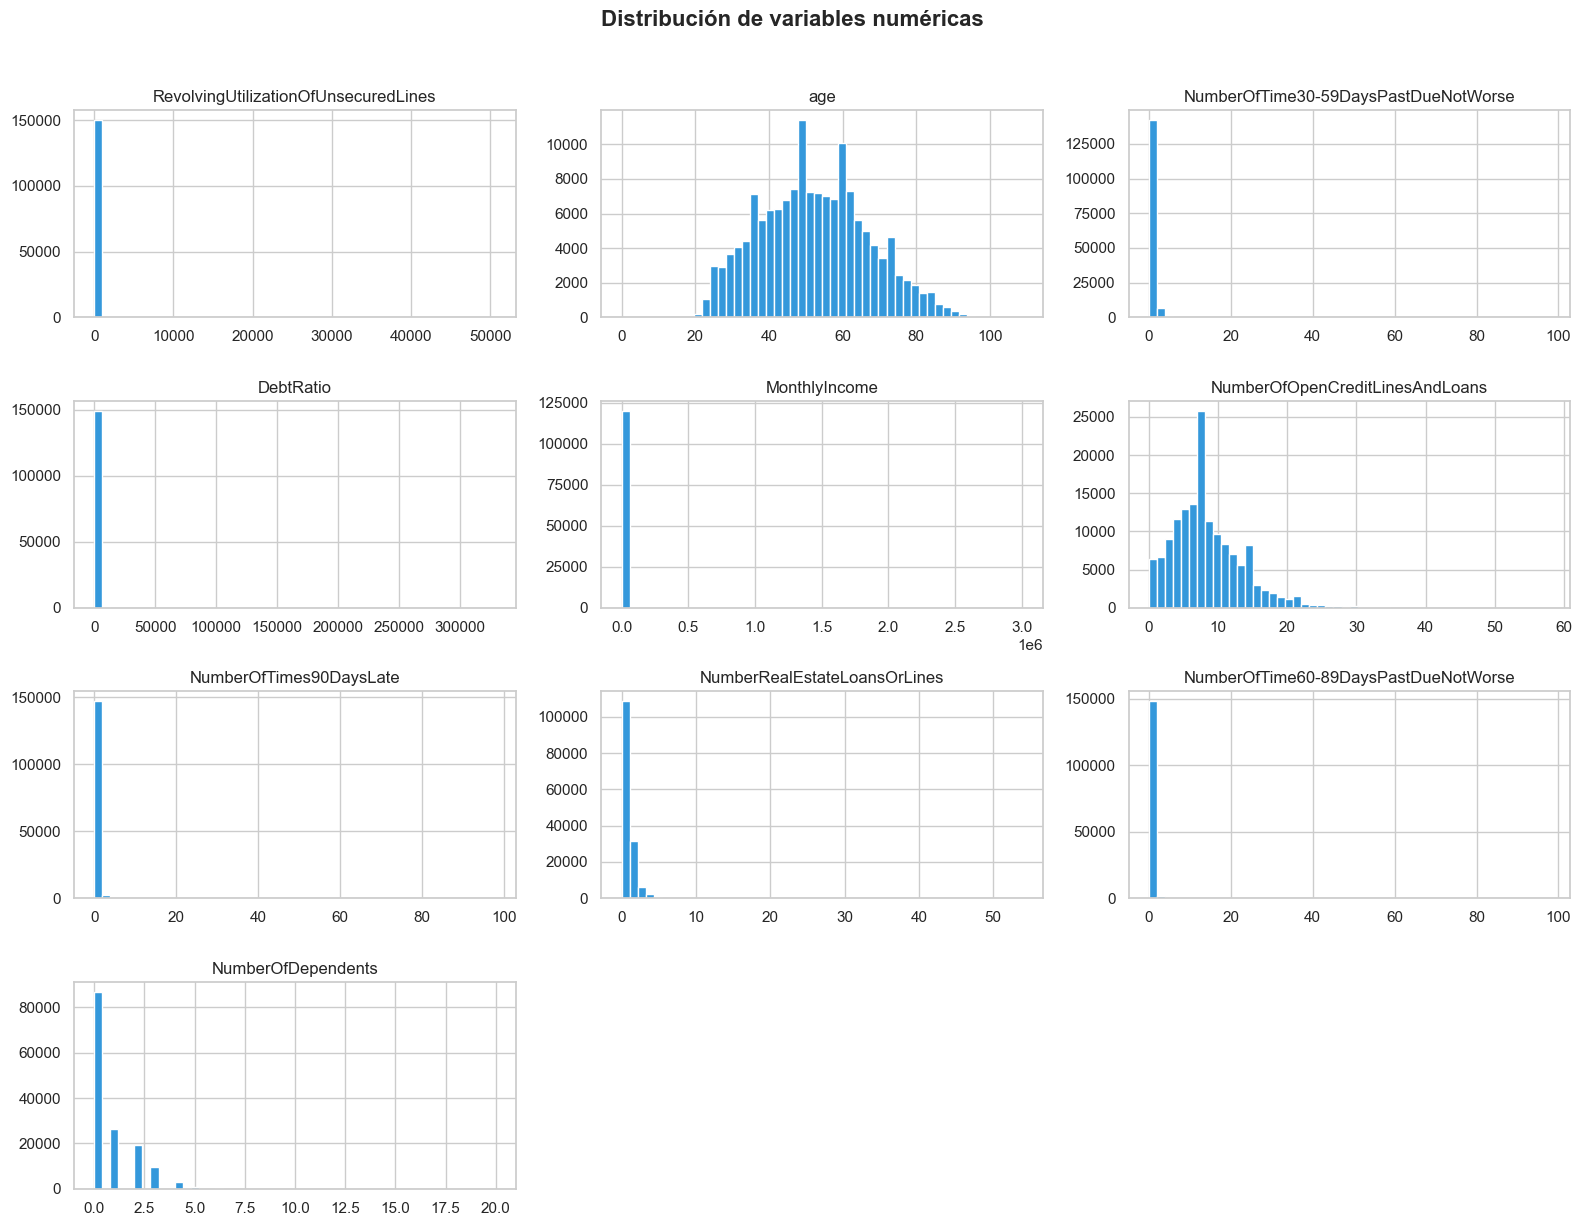

In [13]:
# Variables numéricas que queremos visualizar
# Excluimos 'SeriousDlqin2yrs' porque esa ya la graficamos por separado
columnas = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents'
]

# Generamos los histogramas de todas las variables a la vez
df[columnas].hist(
    bins=50,
    figsize=(16, 12),
    color='#3498db',
    edgecolor='white'
)

plt.suptitle('Distribución de variables numéricas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

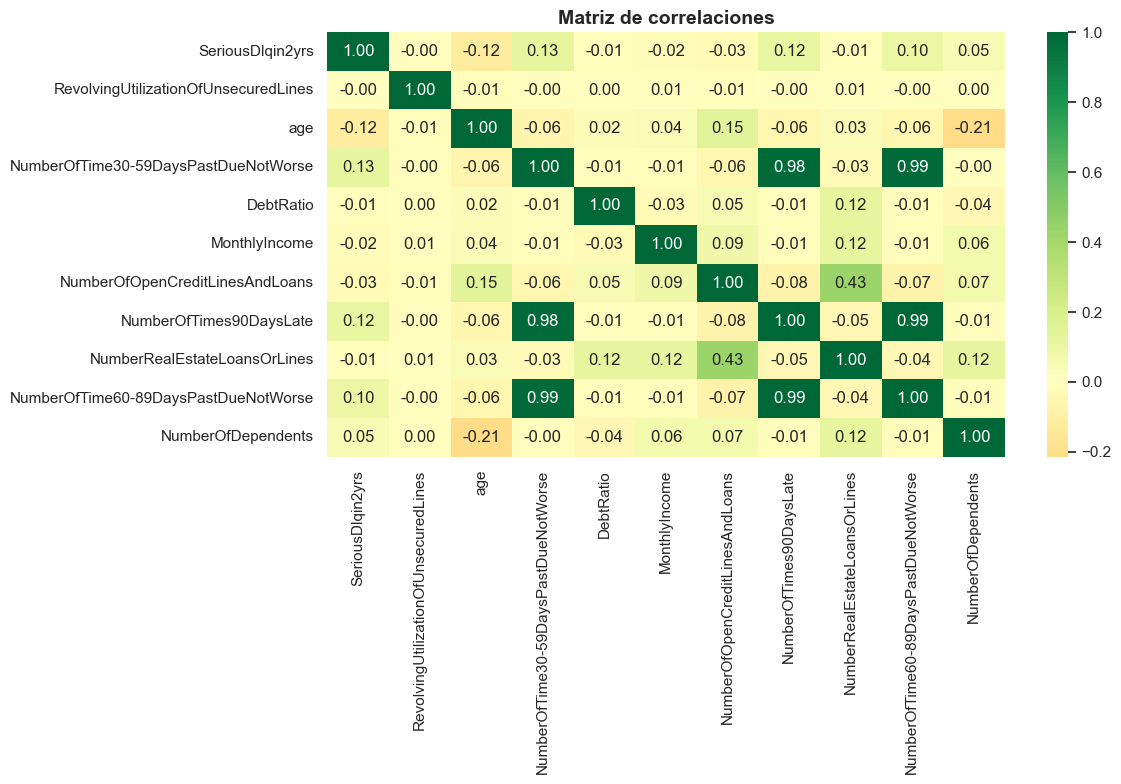

In [14]:
# Calculamos la matriz de correlaciones
correlaciones = df.corr(numeric_only=True)

# Creamos el lienzo
fig, ax = plt.subplots(figsize=(12, 8))

# Dibujamos el heatmap
sns.heatmap(
    correlaciones,
    annot=True,          # muestra el valor numérico en cada celda
    fmt='.2f',           # formato: 2 decimales
    cmap='RdYlGn',       # rojo = correlación negativa, verde = positiva
    center=0,            # el centro de la escala de color es 0
    ax=ax
)

ax.set_title('Matriz de correlaciones', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Calculamos la media de cada variable agrupando por default / no-default
# Esto nos dice: ¿cómo se comporta cada variable en clientes buenos vs malos?
perfil_clientes = df.groupby('SeriousDlqin2yrs')[columnas].mean()

print(perfil_clientes.T)  # .T transpone la tabla para leerla mejor

SeriousDlqin2yrs                           0       1
RevolvingUtilizationOfUnsecuredLines    6.17    4.37
age                                    52.75   45.93
NumberOfTime30-59DaysPastDueNotWorse    0.28    2.39
DebtRatio                             357.15  295.12
MonthlyIncome                        6747.84 5630.83
NumberOfOpenCreditLinesAndLoans         8.49    7.88
NumberOfTimes90DaysLate                 0.14    2.09
NumberRealEstateLoansOrLines            1.02    0.99
NumberOfTime60-89DaysPastDueNotWorse    0.13    1.83
NumberOfDependents                      0.74    0.95


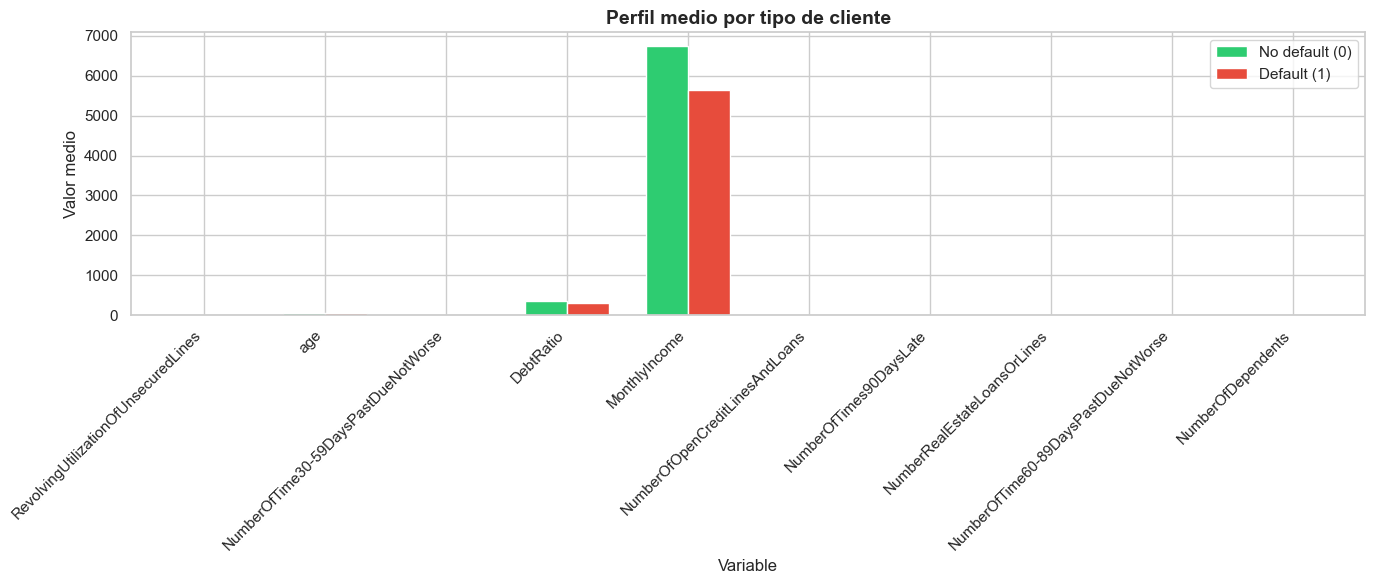

In [16]:
# Transponemos para tener las variables en el eje X
perfil_clientes.T.plot(
    kind='bar',                    # gráfico de barras
    figsize=(14, 6),
    color=['#2ecc71', '#e74c3c'],  # verde para no-default, rojo para default
    edgecolor='white',
    width=0.7
)

plt.title('Perfil medio por tipo de cliente', fontsize=14, fontweight='bold')
plt.xlabel('Variable', fontsize=12)
plt.ylabel('Valor medio', fontsize=12)
plt.xticks(rotation=45, ha='right')  # rotamos etiquetas para que se lean bien
plt.legend(['No default (0)', 'Default (1)'], fontsize=11)
plt.tight_layout()
plt.show()

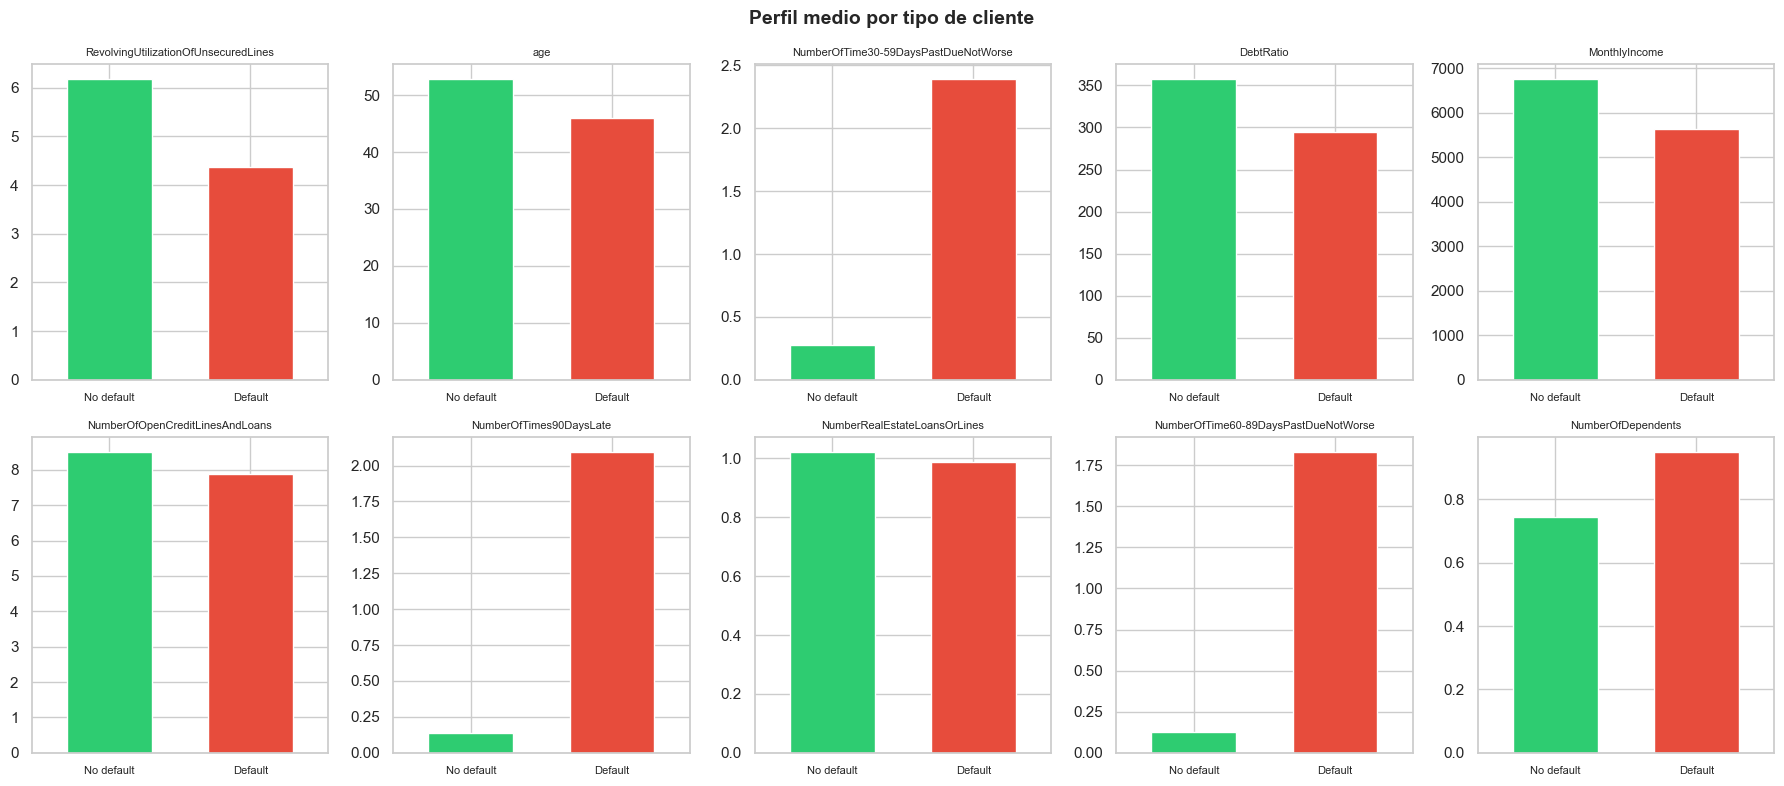

In [17]:
# Graficamos cada variable en su propio subplot con su propia escala
fig, axes = plt.subplots(2, 5, figsize=(18, 8))  # 2 filas, 5 columnas
axes = axes.flatten()  # convertimos la cuadrícula en una lista simple

for i, col in enumerate(columnas):
    perfil_clientes[col].plot(
        kind='bar',
        ax=axes[i],
        color=['#2ecc71', '#e74c3c'],
        edgecolor='white',
        width=0.6
    )
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['No default', 'Default'], rotation=0, fontsize=8)

plt.suptitle('Perfil medio por tipo de cliente', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()